# Focus

This notebooks focus is on getting data from yFinance

In [1]:
print('test to make sure venv is working')

test to make sure venv is working


# Python Imports From Venvironment

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Notebook Settings to Help With Development

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.style.use('seaborn-v0_8')

# Create Folders For Data 

In [4]:
RAW_DATA_PATH = Path('../../data/raw/yfinance')
PROCESSED_DATA_PATH = Path('../../data/processed/yfinance')

In [5]:
# Check to see if the directories exist, if not create 
if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {RAW_DATA_PATH}")
else:
    print(f"Directory already exists: {RAW_DATA_PATH}")

if not PROCESSED_DATA_PATH.exists():
    PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {PROCESSED_DATA_PATH}")
else:
    print(f"Directory already exists: {PROCESSED_DATA_PATH}")

Created directory: ..\..\data\raw\yfinance
Created directory: ..\..\data\processed\yfinance


# Data Tickers and Time Range

In yFinance library data is stored with their ticker symbols.

In [6]:
TICKERS = [
    "QQQ",
    "AAPL",
    "MSFT",
    "LLY",
    "UNH",
    "JPM",
    "V",
    "XOM",
    "PG",
    "KO",
    "CAT",
    "LMT",
    "VNQ",
    "VXUS",
    "TLT",
    "AGG",
    "GLD",
    "AMZN",
    "NEE",
    "VZ",
    "SPY"
]

In [7]:
START_DATE = "2018-01-01" # Doing small sample first
END_DATE = "2025-12-31"  # End date for data acquisition

# Download Data From Yahoo Finance

## NOTE: 
I don't know how big the data is going to be, so I will download a small sample first.

In [8]:
market_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="column",
)

[                       0%                       ]

[*****                 10%                       ]  2 of 21 completed

[*****                 10%                       ]  2 of 21 completed

[*********             19%                       ]  4 of 21 completed

[************          24%                       ]  5 of 21 completed

...

[**********************81%**************         ]  17 of 21 completed

[**********************86%****************       ]  18 of 21 completed

[**********************90%******************     ]  19 of 21 completed

[**********************95%*********************  ]  20 of 21 completed

[*********************100%***********************]  21 of 21 completed

# Investigate the Data

In [9]:
market_data.head()

Price       Adj Close                                                                                             \
Ticker           AAPL        AGG       AMZN         CAT         GLD        JPM         KO        LLY         LMT   
Date                                                                                                               
2018-01-02  40.267082  85.275650  59.450500  131.293884  125.150002  85.901283  35.024231  74.897758  254.261307   
2018-01-03  40.260067  85.283470  60.209999  131.494553  124.820000  85.988808  34.947315  75.304634  256.392395   
2018-01-04  40.447075  85.228775  60.479500  133.300461  125.459999  87.220619  35.439529  75.640739  260.790497   
2018-01-05  40.907566  85.174149  61.457001  135.407288  125.330002  86.660713  35.431843  76.569443  263.153229   
2018-01-08  40.755634  85.150681  62.343498  138.809982  125.309998  86.788719  35.378010  76.180275  261.939941   

Price                                                                                                              \
Ticker           MSFT        NEE         PG         QQQ         SPY        TLT         UNH           V        VNQ   
Date                                                                                                                
2018-01-02  78.699913  31.334093  72.280693  150.057236  235.954269  98.342468  191.993912  107.888260  59.645275   
2018-01-03  79.066170  30.669390  72.193008  151.515289  237.446762  98.812691  194.007950  108.962296  59.472111   
2018-01-04  79.762062  30.511795  72.703293  151.780411  238.447510  98.796982  194.850037  109.367462  58.447609   
2018-01-05  80.750969  30.651194  72.751144  153.304703  240.036514  98.514900  198.565582  111.986694  58.476460   
2018-01-08  80.833374  30.903755  73.133896  153.901215  240.475464  98.452194  195.119110  112.438942  58.779499   

Price                                            Close                                                             \
Ticker           VXUS         VZ        XOM       AAPL         AGG       AMZN         CAT         GLD         JPM   
Date                                                                                                                
2018-01-02  44.600651  33.712944  58.185493  43.064999  109.169998  59.450500  157.039993  125.150002  107.949997   
2018-01-03  44.911568  33.020172  59.328255  43.057499  109.180000  60.209999  157.279999  124.820000  108.059998   
2018-01-04  45.284660  33.127247  59.410366  43.257500  109.110001  60.479500  159.440002  125.459999  109.040001   
2018-01-05  45.587811  33.051674  59.362492  43.750000  109.040001  61.457001  161.960007  125.330002  108.339996   
2018-01-08  45.564491  32.994991  59.629364  43.587502  109.010002  62.343498  166.029999  125.309998  108.500000   

Price                                                                                                              \
Ticker             KO        LLY         LMT       MSFT        NEE         PG         QQQ         SPY         TLT   
Date                                                                                                                
2018-01-02  45.540001  84.680000  318.540009  85.949997  38.772499  90.650002  158.490005  268.769989  125.489998   
2018-01-03  45.439999  85.139999  321.209991  86.349998  37.950001  90.540001  160.029999  270.470001  126.089996   
2018-01-04  46.080002  85.519997  326.720001  87.110001  37.755001  91.180000  160.309998  271.609985  126.070000   
2018-01-05  46.070000  86.570000  329.679993  88.190002  37.927502  91.239998  161.919998  273.420013  125.709999   
2018-01-08  46.000000  86.129997  328.160004  88.279999  38.240002  91.720001  162.550003  273.920013  125.629997   

Price                                                                                High                         \
Ticker             UNH           V        VNQ       VXUS         VZ        XOM       AAPL         AGG       AMZN   
Date                        

In [10]:
market_data.tail()

Price        Adj Close                                                                                                 \
Ticker            AAPL        AGG        AMZN         CAT         GLD         JPM         KO          LLY         LMT   
Date                                                                                                                    
2025-12-23  271.854919  97.842896  232.139999  579.956360  413.640015  322.814331  68.947716  1068.015869  476.898163   
2025-12-24  273.302216  98.058571  232.380005  581.290710  411.929993  326.023376  69.184540  1073.337769  480.060699   
2025-12-26  272.892975  98.078194  232.520004  580.533936  416.739990  324.775421  68.947716  1074.105225  477.372559   
2025-12-29  273.252350  98.195831  232.070007  576.162476  398.600006  320.655182  69.233879  1075.081787  483.144165   
2025-12-30  272.573578  98.156616  232.529999  574.947632  398.890015  320.328339  69.145073  1076.098511  482.284363   

Price                                                                                                                \
Ticker            MSFT        NEE          PG         QQQ         SPY        TLT         UNH           V        VNQ   
Date                                                                                                                  
2025-12-23  484.691528  78.673386  141.108032  620.644470  684.323303  85.559822  320.464050  351.923218  86.485054   
2025-12-24  485.856323  79.324142  142.399094  622.460205  686.730530  86.078072  323.206970  353.675964  87.053909   
2025-12-26  485.547699  79.284714  142.645462  622.420349  686.660889  85.794502  327.400208  353.536560  87.151978   
2025-12-29  484.940430  79.146660  142.477936  619.407410  684.213867  86.117180  324.548828  353.148132  87.328522   
2025-12-30  485.318726  79.403030  141.965454  617.970764  683.378296  85.911827  327.725800  352.162231  87.505066   

Price                                              Close                                                              \
Ticker           VXUS         VZ         XOM        AAPL         AGG        AMZN         CAT         GLD         JPM   
Date                                                                                                                   
2025-12-23  75.133507  38.657764  117.829521  272.359985   99.800003  232.139999  582.419983  413.640015  325.929993   
2025-12-24  75.193176  39.045116  117.632195  273.809998  100.019997  232.380005  583.760010  411.929993  329.170013   
2025-12-26  75.431847  39.200062  117.523659  273.399994  100.040001  232.520004  583.000000  416.739990  327.910004   
2025-12-29  75.193176  39.200062  118.924744  273.760010  100.160004  232.070007  578.609985  398.600006  323.750000   
2025-12-30  75.342346  39.413105  119.378616  273.079987  100.120003  232.529999  577.390015  398.890015  323.420013   

Price                                                                                                                 \
Ticker             KO          LLY         LMT        MSFT        NEE          PG         QQQ         SPY        TLT   
Date                                                                                                                   
2025-12-23  69.870003  1071.640015  482.549988  486.850006  79.790001  143.179993  622.109985  687.960022  87.500000   
2025-12-24  70.110001  1076.979980  485.750000  488.019989  80.449997  144.490005  623.929993  690.380005  88.029999   
2025-12-26  69.870003  1077.750000  483.029999  487.709991  80.410004  144.740005  623.890015  690.309998  87.739998   
2025-12-29  70.160004  1078.729980  488.869995  487.100006  80.269997  144.570007  620.869995  687.849976  88.070000   
2025-12-30  70.070000  1079.750000  488.000000  487.480011  80.529999  144.050003  619.429993  687.010010  87.860001   

Price                                                                                  High                          \
Ticker             UNH           V   

In [11]:
market_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-02 to 2025-12-30
Columns: 126 entries, ('Adj Close', 'AAPL') to ('Volume', 'XOM')
dtypes: float64(105), int64(21)
memory usage: 1.9 MB


In [12]:
market_data.columns

MultiIndex([('Adj Close', 'AAPL'),
            ('Adj Close',  'AGG'),
            ('Adj Close', 'AMZN'),
            ('Adj Close',  'CAT'),
            ('Adj Close',  'GLD'),
            ('Adj Close',  'JPM'),
            ('Adj Close',   'KO'),
            ('Adj Close',  'LLY'),
            ('Adj Close',  'LMT'),
            ('Adj Close', 'MSFT'),
            ...
            (   'Volume',   'PG'),
            (   'Volume',  'QQQ'),
            (   'Volume',  'SPY'),
            (   'Volume',  'TLT'),
            (   'Volume',  'UNH'),
            (   'Volume',    'V'),
            (   'Volume',  'VNQ'),
            (   'Volume', 'VXUS'),
            (   'Volume',   'VZ'),
            (   'Volume',  'XOM')],
           names=['Price', 'Ticker'], length=126)

In [13]:
market_data.columns.names

FrozenList(['Price', 'Ticker'])

In [14]:
# Checking date range
market_data.index.min(), market_data.index.max()

(Timestamp('2018-01-02 00:00:00'), Timestamp('2025-12-30 00:00:00'))

# Download the Data

## NOTE FILE SIZE:
File size: 2722.00 KB

File size: 2.66 MB

In [15]:
market_data.to_csv(RAW_DATA_PATH / "yfinance_market_data.csv")

In [16]:
RAW_DATA_FILE = RAW_DATA_PATH / "yfinance_market_data.csv"

In [17]:
# Checking size of csv file created
if RAW_DATA_FILE.exists():
    file_size_bytes = RAW_DATA_FILE.stat().st_size
    file_size_kb = file_size_bytes / 1024
    file_size_mb = file_size_kb / 1024

print(f"File size: {file_size_bytes:,} bytes")
print(f"File size: {file_size_kb:.2f} KB")
print(f"File size: {file_size_mb:.2f} MB")

File size: 4,112,949 bytes
File size: 4016.55 KB
File size: 3.92 MB


# Adjust Data 

In [18]:
adjust_close = market_data['Adj Close']

In [19]:
adjust_close.head()

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267082,85.275650,59.450500,131.293884,125.150002,85.901283,35.024231,74.897758,254.261307,78.699913,31.334093,72.280693,150.057236,235.954269,98.342468,191.993912,107.888260,59.645275,44.600651,33.712944,58.185493
2018-01-03,40.260067,85.283470,60.209999,131.494553,124.820000,85.988808,34.947315,75.304634,256.392395,79.066170,30.669390,72.193008,151.515289,237.446762,98.812691,194.007950,108.962296,59.472111,44.911568,33.020172,59.328255
2018-01-04,40.447075,85.228775,60.479500,133.300461,125.459999,87.220619,35.439529,75.640739,260.790497,79.762062,30.511795,72.703293,151.780411,238.447510,98.796982,194.850037,109.367462,58.447609,45.284660,33.127247,59.410366
2018-01-05,40.907566,85.174149,61.457001,135.407288,125.330002,86.660713,35.431843,76.569443,263.153229,80.750969,30.651194,72.751144,153.304703,240.036514,98.514900,198.565582,111.986694,58.476460,45.587811,33.051674,59.362492
2018-01-08,40.755634,85.150681,62.343498,138.809982,125.309998,86.788719,35.378010,76.180275,261.939941,80.833374,30.903755,73.133896,153.901215,240.475464,98.452194,195.119110,112.438942,58.779499,45.564491,32.994991,59.629364


In [20]:
adjust_close.columns

Index(['AAPL', 'AGG', 'AMZN', 'CAT', 'GLD', 'JPM', 'KO', 'LLY', 'LMT', 'MSFT', 'NEE', 'PG', 'QQQ', 'SPY', 'TLT', 'UNH',
       'V', 'VNQ', 'VXUS', 'VZ', 'XOM'],
      dtype='str', name='Ticker')

In [21]:
# NO MISSING COLUMNS (Means all Tickers had adjusted closes)
set(TICKERS) - set(adjust_close.columns)

set()

In [22]:
# No missing vals
adjust_close.isna().sum()

Ticker
AAPL    0
AGG     0
AMZN    0
CAT     0
GLD     0
JPM     0
KO      0
LLY     0
LMT     0
MSFT    0
NEE     0
PG      0
QQQ     0
SPY     0
TLT     0
UNH     0
V       0
VNQ     0
VXUS    0
VZ      0
XOM     0
dtype: int64

In [23]:
adjust_close.isna().mean().sort_values(ascending=False)

Ticker
AAPL    0.0
AGG     0.0
AMZN    0.0
CAT     0.0
GLD     0.0
JPM     0.0
KO      0.0
LLY     0.0
LMT     0.0
MSFT    0.0
NEE     0.0
PG      0.0
QQQ     0.0
SPY     0.0
TLT     0.0
UNH     0.0
V       0.0
VNQ     0.0
VXUS    0.0
VZ      0.0
XOM     0.0
dtype: float64

In [24]:
adjust_close.describe()

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
count,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000
mean,135.197352,91.444346,140.249155,217.649474,184.049686,141.868667,50.173938,364.034968,364.194404,262.908178,59.981087,121.846737,321.299196,391.856158,101.797085,362.665431,216.230813,74.322233,50.468665,37.081269,73.033731
std,66.638825,5.275851,46.975385,108.954978,60.698379,62.136530,10.515617,287.023765,79.532741,125.318736,14.588523,29.812959,128.088059,123.858785,17.864661,116.762168,64.494206,10.934359,8.564662,4.290025,27.560604
min,33.736992,81.825462,59.450500,81.300629,111.099998,66.763321,31.103399,65.637276,200.768677,77.839203,29.354116,57.523396,137.012772,204.418213,73.702675,175.098053,107.275833,44.828869,30.442949,26.051186,23.823563
25%,64.261496,87.078381,94.568752,125.553492,144.132496,92.631569,41.351381,120.765265,302.501602,145.044800,49.221878,102.082743,195.014313,271.733849,86.557714,244.347931,171.865017,65.975044,43.587925,34.196756,51.379762
50%,142.669800,91.459934,140.480003,191.804863,170.630005,124.393818,49.399717,250.065781,347.519928,250.312798,64.707157,127.065979,308.761093,385.406784,95.412941,363.974869,206.861092,73.691822,49.769560,38.440208,60.528421
75%,182.517319,96.872177,173.360752,277.114456,188.075005,159.572346,57.062210,600.889420,428.215096,367.423660,70.755287,144.418304,401.198212,458.845619,116.857264,470.089767,254.087017,85.147289,55.995850,40.514891,100.759832
max,285.659271,100.316818,254.000000,622.963623,416.739990,326.023376,71.651543,1106.186279,586.341248,538.658508,85.082420,172.541000,633.456238,686.730530,142.699585,599.775574,370.384399,97.226730,75.431847,44.310101,119.378616


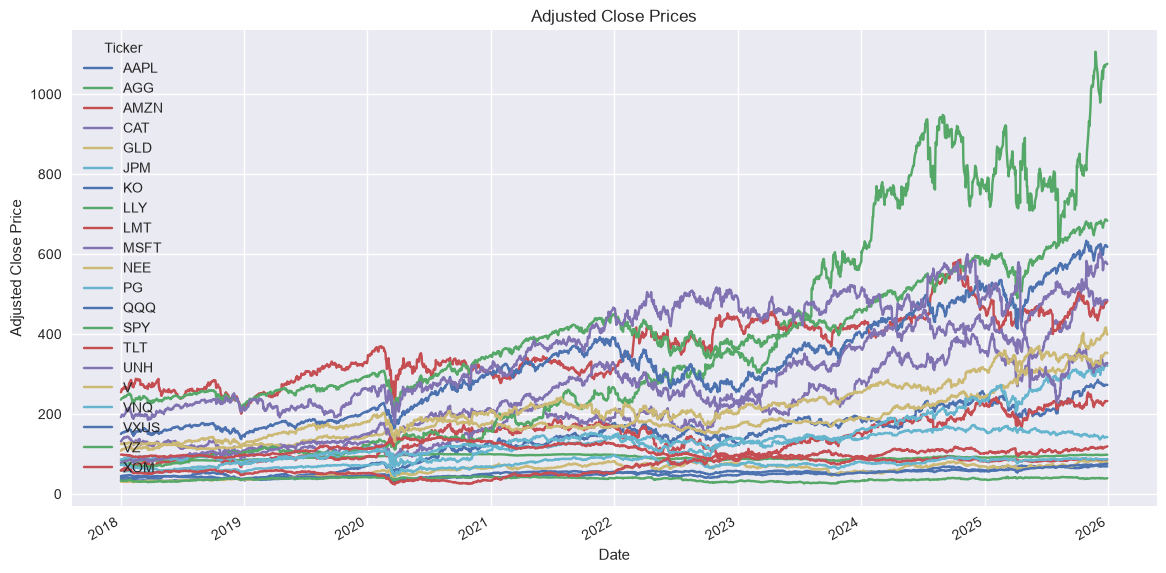

In [25]:
adjust_close.plot(figsize=(14, 7), title="Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()

This chart shows the raw adjusted close price for each asset. Since assets have different price levels, this chart will be useful for checking whether the downloade data looks reasonable and realistic. 

This is biased, so we will need to normalize prices and returns.

# Normalize Prices

In [26]:
# Take every price and divide by its firce price which reprents its growth
'''
APPLE
Date   | AAPL Price | Normalized
Day 1    100          100/100 = 1.00
Day 2    110          110/100 = 1.10
Day 3    95           95/100  =  0.95
'''

normalized_prices = adjust_close / adjust_close.iloc[0]


normalized_prices.head()

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-03,0.999826,1.000092,1.012775,1.001528,0.997363,1.001019,0.997804,1.005432,1.008381,1.004654,0.978787,0.998787,1.009717,1.006325,1.004781,1.010490,1.009955,0.997097,1.006971,0.979451,1.019640
2018-01-04,1.004470,0.999450,1.017309,1.015283,1.002477,1.015359,1.011857,1.009920,1.025679,1.013496,0.973757,1.005847,1.011483,1.010567,1.004622,1.014876,1.013711,0.979920,1.015336,0.982627,1.021051
2018-01-05,1.015906,0.998810,1.033751,1.031330,1.001438,1.008841,1.011638,1.022320,1.034972,1.026062,0.978206,1.006509,1.021642,1.017301,1.001753,1.034229,1.037988,0.980404,1.022133,0.980385,1.020228
2018-01-08,1.012133,0.998535,1.048662,1.057246,1.001278,1.010331,1.010101,1.017124,1.030200,1.027109,0.986266,1.011804,1.025617,1.019161,1.001116,1.016278,1.042180,0.985485,1.021610,0.978704,1.024815


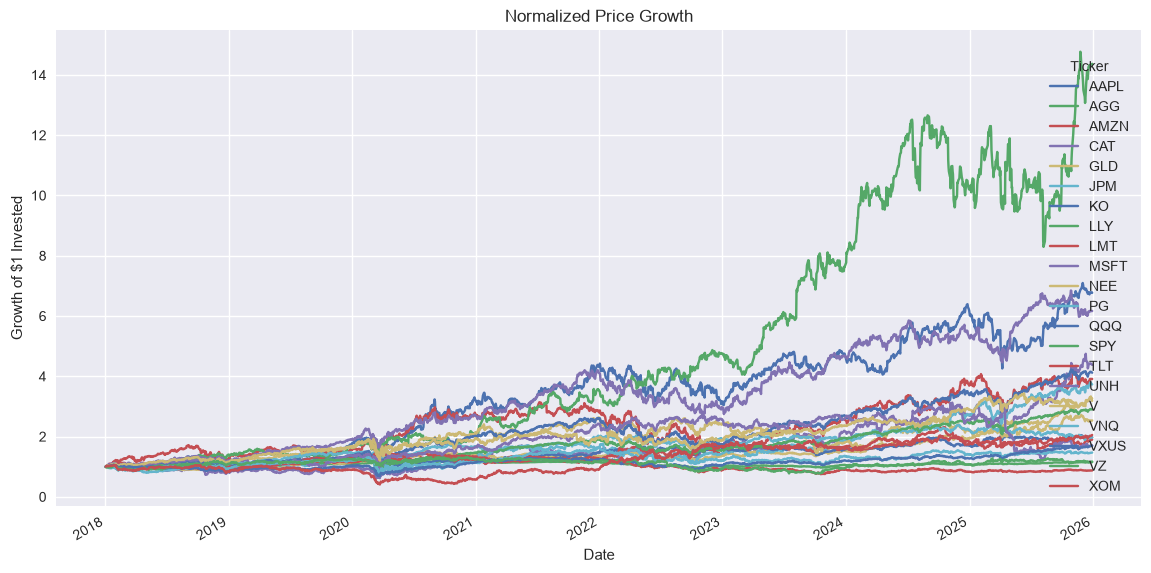

In [27]:
normalized_prices.plot(figsize=(14, 7), title="Normalized Price Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.show()

This normalzied chart compares how $1 invested ine each of the chosen assets would have grown over time. This makes the assets easier to compare than raw price levels because of bias towards larger companies.

# Calculate Daily Returns

In [28]:
daily_returns = adjust_close.pct_change()

In [29]:
daily_returns.head()

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.000092,0.012775,0.001528,-0.002637,0.001019,-0.002196,0.005432,0.008381,0.004654,-0.021213,-0.001213,0.009717,0.006325,0.004781,0.010490,0.009955,-0.002903,0.006971,-0.020549,0.019640
2018-01-04,0.004645,-0.000641,0.004476,0.013734,0.005127,0.014325,0.014084,0.004463,0.017154,0.008801,-0.005139,0.007068,0.001750,0.004215,-0.000159,0.004340,0.003718,-0.017227,0.008307,0.003243,0.001384
2018-01-05,0.011385,-0.000641,0.016163,0.015805,-0.001036,-0.006419,-0.000217,0.012278,0.009060,0.012398,0.004569,0.000658,0.010043,0.006664,-0.002855,0.019069,0.023949,0.000494,0.006694,-0.002281,-0.000806
2018-01-08,-0.003714,-0.000276,0.014425,0.025129,-0.000160,0.001477,-0.001519,-0.005083,-0.004611,0.001020,0.008240,0.005261,0.003891,0.001829,-0.000637,-0.017357,0.004038,0.005182,-0.000512,-0.001715,0.004496


In [30]:
daily_returns.describe()

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
count,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000
mean,0.001140,0.000077,0.000914,0.000936,0.000623,0.000822,0.000413,0.001520,0.000442,0.001065,0.000609,0.000415,0.000820,0.000605,-0.000018,0.000465,0.000722,0.000290,0.000324,0.000162,0.000538
std,0.019401,0.003669,0.021680,0.020035,0.009535,0.018298,0.012163,0.019741,0.015659,0.017861,0.017092,0.012591,0.015153,0.012260,0.009923,0.019772,0.016307,0.014006,0.011224,0.012987,0.018996
min,-0.128647,-0.040010,-0.140494,-0.142822,-0.064269,-0.149649,-0.096725,-0.141364,-0.127616,-0.147390,-0.134171,-0.087373,-0.119788,-0.109424,-0.066682,-0.223797,-0.135472,-0.177277,-0.111318,-0.074978,-0.122248
25%,-0.007925,-0.001631,-0.010250,-0.009349,-0.004385,-0.007638,-0.005262,-0.007835,-0.005936,-0.007372,-0.007500,-0.005599,-0.005958,-0.004280,-0.005967,-0.007681,-0.006954,-0.006109,-0.005073,-0.005906,-0.009448
50%,0.001187,0.000177,0.001084,0.000780,0.000646,0.000872,0.000643,0.001662,0.000699,0.001254,0.001107,0.000730,0.001365,0.000899,0.000167,0.000827,0.001423,0.000745,0.000887,0.000346,0.000481
75%,0.011071,0.001850,0.012258,0.011852,0.005667,0.009361,0.006276,0.010271,0.007668,0.010266,0.009033,0.006882,0.008557,0.006519,0.005736,0.009269,0.008477,0.007230,0.006099,0.006632,0.010648
max,0.153288,0.023721,0.135359,0.116346,0.048530,0.180125,0.064796,0.156798,0.107280,0.142169,0.136904,0.120090,0.120031,0.105019,0.075196,0.127989,0.138427,0.089966,0.083810,0.092705,0.126868


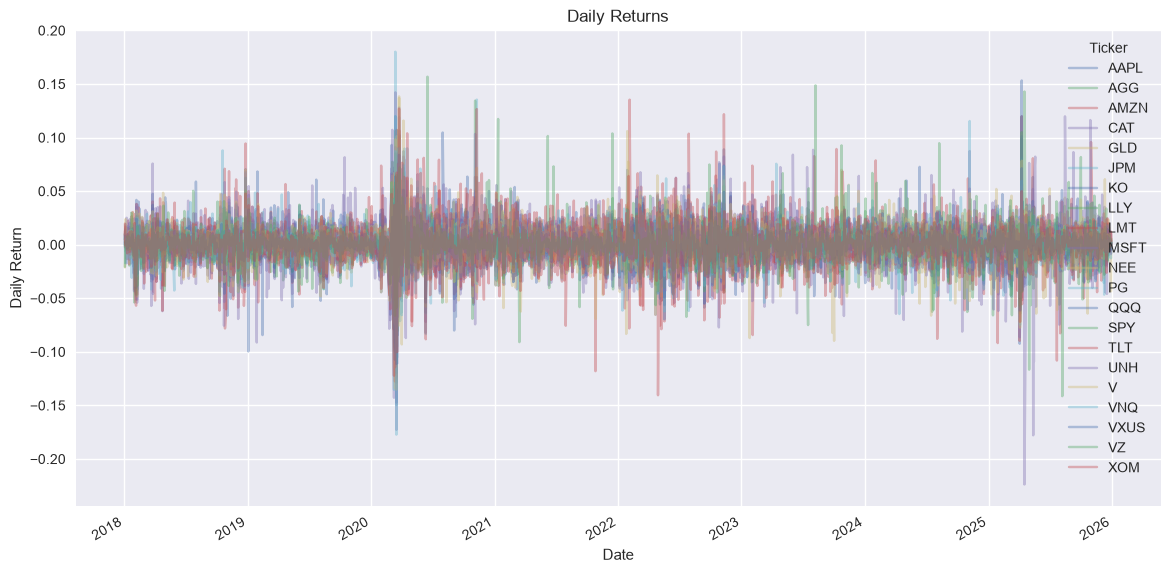

In [31]:
daily_returns.plot(figsize=(14, 7), alpha=0.4, title="Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

Daily returns are noisy as a data point, but it helps show how each one is moving from each trading day. We can ues these later to calculate volatility, covariance, correlation, and portfolio performance

In [32]:
return_correlation = daily_returns.corr()

return_correlation

Ticker,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.110501,0.595106,0.400360,0.065187,0.430872,0.354117,0.285458,0.280608,0.700310,0.331642,0.361664,0.817421,0.774846,-0.090532,0.328367,0.583774,0.504342,0.621377,0.226348,0.309200
AGG,0.110501,1.000000,0.113777,-0.024418,0.326898,-0.034032,0.122960,0.043949,0.005083,0.107344,0.256154,0.118648,0.132857,0.135169,0.835494,0.033276,0.087136,0.279620,0.185890,0.084008,-0.030087
AMZN,0.595106,0.113777,1.000000,0.335526,0.058790,0.324663,0.169215,0.223220,0.161229,0.682078,0.223793,0.189718,0.782095,0.673842,-0.035785,0.218762,0.458697,0.363835,0.521194,0.115304,0.179402
CAT,0.400360,-0.024418,0.335526,1.000000,0.037601,0.613845,0.323578,0.223214,0.349172,0.403410,0.229463,0.224123,0.522771,0.650271,-0.227488,0.277477,0.484975,0.465745,0.628215,0.258247,0.551482
GLD,0.065187,0.326898,0.058790,0.037601,1.000000,-0.034106,0.081085,0.042813,0.088928,0.061976,0.178721,0.073715,0.103189,0.095513,0.251099,0.034368,0.032474,0.147637,0.233650,0.072764,0.061373
JPM,0.430872,-0.034032,0.324663,0.613845,-0.034106,1.000000,0.446771,0.242649,0.371428,0.443961,0.290933,0.317210,0.538879,0.713632,-0.292413,0.365276,0.597037,0.574584,0.666980,0.314758,0.546903
KO,0.354117,0.122960,0.169215,0.323578,0.081085,0.446771,1.000000,0.295276,0.466064,0.357035,0.506407,0.627745,0.374651,0.535512,-0.091449,0.358995,0.493057,0.606777,0.489395,0.466560,0.376549
LLY,0.285458,0.043949,0.223220,0.223214,0.042813,0.242649,0.295276,1.000000,0.261419,0.320505,0.258491,0.338809,0.356746,0.414688,-0.066190,0.276325,0.308344,0.321873,0.320434,0.234346,0.199095
LMT,0.280608,0.005083,0.161229,0.349172,0.088928,0.371428,0.466064,0.261419,1.000000,0.290237,0.328824,0.370430,0.313336,0.443088,-0.159288,0.347633,0.392138,0.417391,0.378506,0.294886,0.382996


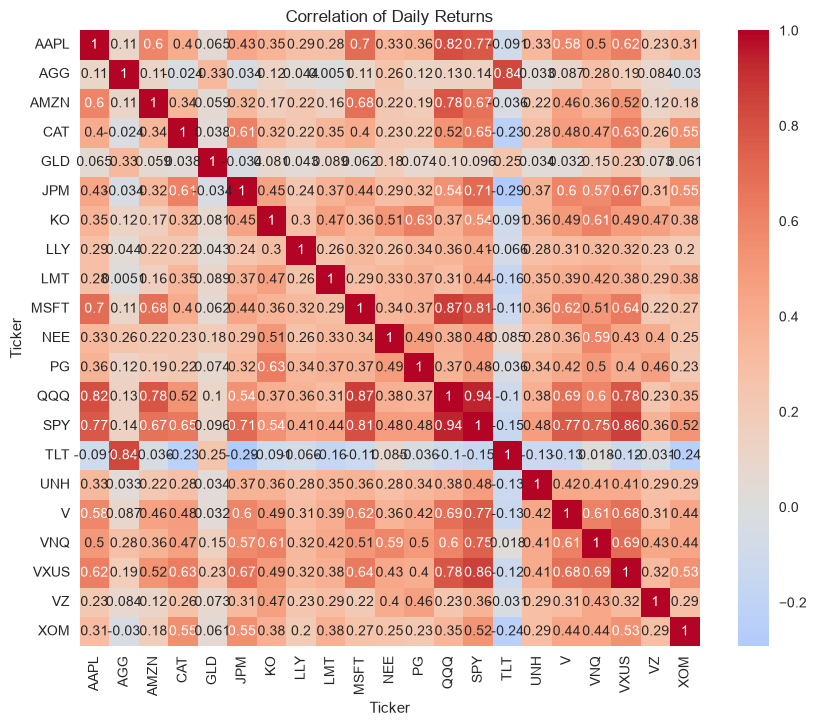

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(return_correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Daily Returns")
plt.show()

We can use this correlation heat map to help us understand which assets/tickers tend to move together. This will be important for portfolio diverisifcation depending on combining assets that are not perfectly correlated.

# Get Basic Annualized Metrics

In [34]:
TRADING_DAYS = 252

annualized_return = daily_returns.mean() * TRADING_DAYS
annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)

print(annualized_return)
print(annualized_volatility)

Ticker
AAPL    0.287326
AGG     0.019346
AMZN    0.230284
CAT     0.235961
GLD     0.156912
JPM     0.207217
KO      0.104066
LLY     0.383132
LMT     0.111428
MSFT    0.268446
NEE     0.153583
PG      0.104637
QQQ     0.206583
SPY     0.152411
TLT    -0.004559
UNH     0.117255
V       0.181890
VNQ     0.073090
VXUS    0.081760
VZ      0.040855
XOM     0.135652
dtype: float64
Ticker
AAPL    0.307982
AGG     0.058242
AMZN    0.344154
CAT     0.318047
GLD     0.151369
JPM     0.290465
KO      0.193087
LLY     0.313381
LMT     0.248579
MSFT    0.283531
NEE     0.271335
PG      0.199871
QQQ     0.240550
SPY     0.194623
TLT     0.157517
UNH     0.313868
V       0.258870
VNQ     0.222342
VXUS    0.178175
VZ      0.206163
XOM     0.301556
dtype: float64


In [35]:
summary_stats = pd.DataFrame({
    "annualized_return" : annualized_return,
    "annualized_volatility" : annualized_volatility
})

summary_stats

,annualized_return,annualized_volatility
Ticker,,
AAPL,0.287326,0.307982
AGG,0.019346,0.058242
AMZN,0.230284,0.344154
CAT,0.235961,0.318047
GLD,0.156912,0.151369
JPM,0.207217,0.290465
KO,0.104066,0.193087
LLY,0.383132,0.313381
LMT,0.111428,0.248579


# Risk Return Scatterplot

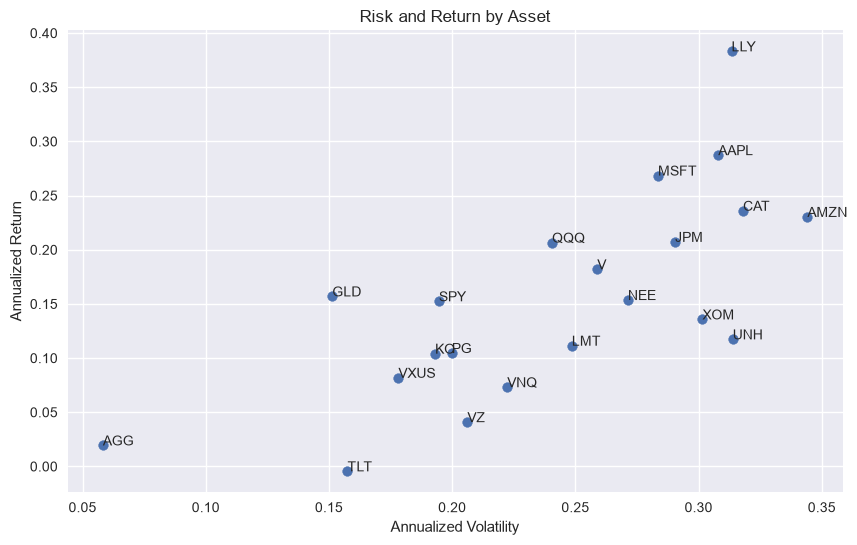

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(
    summary_stats["annualized_volatility"],
    summary_stats["annualized_return"]
)

for ticker in summary_stats.index:
    plt.text(
        summary_stats.loc[ticker, "annualized_volatility"],
        summary_stats.loc[ticker, "annualized_return"],
        ticker
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk and Return by Asset")
plt.show()

This chart gives an initial view of the risk-return tradeoff for each asset. Assets farther to the right have higher volatility, while the assets higher on the chart have higher historical annualized return.

# Save Outputs

In [37]:
adjust_close.to_csv(RAW_DATA_PATH / "yfinance_adjusted_close_prices.csv")
daily_returns.to_csv(RAW_DATA_PATH / "yfinance_daily_returns_initial.csv")
summary_stats.to_csv(RAW_DATA_PATH / "yfinance_initial_summary_stats.csv")

In [38]:
print("Worked")

Worked


# Conclusion

## Initial Exploration Summary

In this notebook, we downloaded historical market data for selected assets. Leaning more top companies which tend to be technology, but we are able to adjust in future. Then we perofrmed an initial data quality check.

## Main Takeaways

- Data was able to adjust
- Adjusted close prices are available easily and can be used for return calculations.
- The data is able to cover for data from 2018 to 2025.
- Daily returns show differences in volatility across different assets.
- The corrleation heatmaps show there are assets that move together, while others don't move together which will be good for diversification.
- Our next step is for preprocessing, where we clean teh data, handle missing vals, align dates more explicit, and create a final processed dataset.